In [107]:
import sys
import os
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_teddynote import logging
from langchain.agents.middleware import TodoListMiddleware
from langchain.agents import create_agent
from pathlib import Path
from IPython.display import Markdown, display
from __future__ import annotations
from typing import List, Literal, Optional, TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_teddynote.graphs import visualize_graph

from dotenv import load_dotenv

load_dotenv(override=True)

# 추적을 위한 프로젝트 이름 설정
logging.langsmith("Samsung-Asset-AI-Portal")

# prompt 모듈에서 필요한 항목 import
from prompt import (
    _SYSTEM_PROMPT,
    _SYSTEM_PROMPT_ENG,
    get_prompt_pdf_text_to_markdown,
    get_prompt_text_to_markdown,
    get_prompt_pdf_text_to_markdown_validate,
    get_prompt_text_to_markdown_validate,
    get_prompt_confirmed_expected_clarification,
    get_prompt_text_to_markdown_validate_report,
    get_prompt_text_to_markdown_error_fix,
    get_prompt_confirmed_expected_clarification_validate_report,
    get_prompt_confirmed_expected_clarification_error_fix,
    get_prompt_text_to_markdown_with_validate
)

# document_parser 모듈에서 필요한 함수들 import
from document_parser import (
    extract_pdf_with_docling,
    extract_pdf_with_pdfplumber,
    parser_excel,
    get_file_path,
    get_last_ai_message
)

from utils import (
    format_messages,
    extract_validate_result,
    has_validate_result,
    check_validate_result,
)

from llm_util import StreamPrinter

_original_text = None

LangSmith 추적을 시작합니다.
[프로젝트명]
Samsung-Asset-AI-Portal


In [108]:
# LLM 모델 정의

from gc import callbacks


LLM_MODEL = os.getenv("LLM_MODEL")
LLM_BASE_URL=os.getenv("LLM_BASE_URL")
LLM_API_KEY=os.getenv("LLM_API_KEY")

def create_llm_model(stream_prifix:str=""):

    # vLLM 모델 인스턴스 생성
    llm = init_chat_model(
        "openai:",
        temperature=0.0,
        top_p=0.1,  # top_p는 (0, 1] 범위여야 하므로 0.1로 설정
        base_url=LLM_BASE_URL,
        api_key=LLM_API_KEY,
        streaming=True,
        callbacks=[StreamPrinter(stream_prifix)]
    )
    # llm = init_chat_model(
    #     "openai:gpt-4o",
    #     temperature=0.0,
    #     top_p=0.1,  # top_p는 (0, 1] 범위여야 하므로 0.9로 설정
    # )
    return llm

# 출력 구조화 - 스키마 정의

In [109]:
class KV(BaseModel):
    key: str
    value: str
    # evidence: str = Field(description="원문에서 value를 뒷받침하는 근거 문자열(가능하면 그대로 인용)")


class FundRow(BaseModel):
    row_type: Literal["fund", "summary", "blank", "unknown"]
    # bucket: Literal["확정분", "청구분", "거래없음", "불명"]
    field: List[KV]
    notes: Optional[str] = None


class ExtractionResult(BaseModel):
    metadata_items: List[KV]
    fund_rows: List[FundRow]
    issues: List[str] = Field(default_factory=list) # ExtractionResult 인스턴스 생성 시 초기화 시키는 코드

# Graph 상태 정의

In [110]:
class RState(TypedDict):
    file_path: str # 변액일임펀드 설정/해지 지시서 파일 경로
    file_name: str # 지시서 파일 이름
    file_ext: str # 지시서 파일 확장자
    password: str # 지시서 암호
    raw_text: str
    cleaned_text: str
    raw_text_docling: str # 지시서 원본 텍스트 - docling
    raw_text_pdfplumber: str # 지시서 원본 텍스트 - pdfplumber    
    cleaned_text_docling: str # 지시서 원본 텍스트 - docling
    cleaned_text_pdfplumber: str # 지시서 원본 텍스트 - pdfplumber
    markdown_text: str # 지시서 마크다운 텍스트
    result: Optional[ExtractionResult]
    validation_ok: bool
    iterations: int

# LLM - 메타 데이터 수집 체인

In [111]:
model = create_llm_model("extract")

# 출력 구조화 강제
extractor_llm = model.with_structured_output(ExtractionResult)

# Util

In [112]:
# 전처리, 공백정리, PDF 변환 시 생성되는 단어 정리
def text_preprocess(raw_text: str) -> str:    
    for junk in ["<!-- pagebreak -->", "<!-- image -->"]:
        raw_text = raw_text.replace(junk, " ")

    cleaned_text = " ".join(raw_text.split())
    return cleaned_text

# excel to markdown

In [113]:
# 싱글톤 

def text_to_markdown_with_llm(document_text: str):
    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_text_to_markdown_with_validate(document_text)
    # human_prompt = get_prompt_text_to_markdown(document_text)
    print("########## text to markdown prompt ##########")
    print(human_prompt)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# todos 미들웨어 사용
def text_to_markdown_with_plan(document_text: str):
    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown(document_text)
    print("########## text to markdown prompt ##########")
    print(human_prompt)
    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

def convert_excel_to_markdown(file_path: str):
    # 엑셀 파일 경로 확인
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    # 엑셀 파일에서 텍스트 추출
    _original_text = parser_excel(file_path)

    # 텍스트를 markdown으로 변환
    # response_markdown = text_to_markdown_with_plan(document_text_excel)
    response_markdown = text_to_markdown_with_llm(_original_text)
    # markdown_text = get_last_ai_message(response_markdown)

    return response_markdown


# Data Extract - structure

In [114]:
# markdown으로 변환된 지시서에서 데이터 추출 : json 형식
def data_extract_to_structure(document_text:str):
    human_prompt = f"""    
당신은 자산운용사 변액일임펀드 설정/해지 지시서에서 데이터를 추출하는 추론 에이전트입니다.
아래의 문서는 수익자가 보내온 변액일임펀드 설정/해지 지시서 파일에서 추출한 텍스트입니다.
아래 문서 텍스트에서 중요 규칙에 따라 "있는 그대로" 데이터를 구조화해서 추출하세요.

[중요 규칙]
- 문서에 없는 값은 절대 만들지 말 것(추측 금지).
- 문서상의 메타데이터를 key/value로 수집.
- 펀드 거래 데이터 표가 있다면 "펀드 행"을 행 단위로 펀드코드, 펀드명, 날짜, 금액 정보만 수집(요약/합계 행은 row_type=summary로 분리).

[출력 규칙]
- 출력은 반드시 JSON만 출력한다. (설명 문장, 마크다운, 코드펜스 금지)
- JSON 이외의 어떤 문자도 앞/뒤에 출력하지 말 것.
- 스키마에 없는 필드는 추가하지 말 것.

[문서]
{document_text}
    """
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_msg = HumanMessage(human_prompt)
    messages = [system_msg, human_msg]

    print("########## data_extract_to_structure prompt ##########")
    print(human_prompt)

    result: ExtractionResult = extractor_llm.invoke(messages)
    return result

# Node 구현

In [115]:
# 지시서 문서 정보 수집
def node_get_document_info(state: RState) -> RState:
    file_path = state["file_path"]
    
    # file_path에서 파일명과 확장자 추출    
    path_obj = Path(file_path)
    file_name = path_obj.name  # 파일명 (확장자 포함)
    file_ext = path_obj.suffix  # 확장자 (점 포함, 예: .pdf)

    print(f"   file_path : {file_path}")
    print(f"   file_name : {file_name}")
    print(f"   file_ext : {file_ext}")
    
    return {"file_name": file_name, "file_ext": file_ext}

In [116]:
# 노드 - PDF 문서 파싱 - docling
def node_parse_pdf_document_docling(state: RState) -> RState:
    file_path = state["file_path"]
    password = state["password"]
    raw_pdf_text = extract_pdf_with_docling(file_path, password)
    cleaned_pdf_text = text_preprocess(raw_pdf_text)

    print("docling")
    # print(pdf_text)

    return {
        **state,
        "raw_text_docling": raw_pdf_text,
        "cleaned_text_docling": cleaned_pdf_text
    }


In [117]:
# 노드 - PDF 문서 파싱 - pdfplumber
def node_parse_pdf_document_pdfplumber(state: RState) -> RState:
    file_path = state["file_path"]
    password = state["password"]
    raw_pdf_text = extract_pdf_with_pdfplumber(file_path, password)
    cleaned_pdf_text = text_preprocess(raw_pdf_text)

    print("pdfplumber")
    # print(pdf_text)

    return {
        **state,
        "raw_text_pdfplumber": raw_pdf_text,
        "cleaned_text_pdfplumber": cleaned_pdf_text
    }

In [118]:
def node_parse_excel_document(state: RState) -> RState:
    file_path = state["file_path"]
    raw_text = parser_excel(file_path)
    cleaned_text = text_preprocess(raw_text)

    # print("****************excel parser****************")
    # print(f"   {original_text}")
    
    return {
        **state,
        "raw_text": raw_text,
        "cleaned_text": cleaned_text
    }


In [119]:
def node_text_to_markdown(state: RState) -> RState:
    print("****************START node_convert_text_to_markdown****************")
    file_ext = state["file_ext"]
    markdown_text = None

    if file_ext == ".pdf":
        document_text_docling = state["cleaned_text_docling"]
        document_text_pdfplumber = state["cleaned_text_pdfplumber"]
        # response = convert_pdf_text_to_markdown_using_agent(document_text_docling, document_text_pdfplumber)
        # response = convert_pdf_text_to_markdown(document_text_docling, document_text_pdfplumber)        
        print("****************pdf markdown****************")
        # markdown_text = response.content
        # print(f"   {markdown_text}")
    elif file_ext == ".xlsx" or state["file_ext"] == ".xls":
        original_text = state["cleaned_text"]  
        response = text_to_markdown_with_llm(original_text)
        print("****************excel markdown****************")
    else:
        original_text = state["cleaned_text"]
        response = text_to_markdown_with_llm(original_text)        
        print("****************unknown markdown****************")

    markdown_text = response.content

    print(markdown_text)

    return {
        **state,
        "markdown_text": markdown_text
    }


In [120]:
def node_data_extract(state: RState) -> RState:    
    markdown_text = state['markdown_text']
    result_extracted_data = data_extract_to_structure(markdown_text)
    return {**state, "result": result_extracted_data}


def node_data_extract_with_cleaned_text(state: RState) -> RState:    
    cleaned_text = state['cleaned_text']
    result_extracted_data = data_extract_to_structure(cleaned_text)
    return {**state, "result": result_extracted_data}

In [121]:
def node_complete(state: RState) -> RState:
    print("****************END****************")
    return


# Graph 생성

In [122]:
# graph 객체 생성
graph_builder = StateGraph(RState)

In [123]:
# node 생성
graph_builder.add_node("node_get_document_info", node_get_document_info)
graph_builder.add_node("node_parse_excel_document", node_parse_excel_document)
graph_builder.add_node("node_parse_pdf_document_docling", node_parse_pdf_document_docling)
graph_builder.add_node("node_parse_pdf_document_pdfplumber", node_parse_pdf_document_pdfplumber)
graph_builder.add_node("node_text_to_markdown", node_text_to_markdown)
graph_builder.add_node("node_data_extract", node_data_extract)
graph_builder.add_node("node_data_extract_with_cleaned_text", node_data_extract_with_cleaned_text)
graph_builder.add_node("node_complete", node_complete)

In [124]:
# node 연결
graph_builder.add_edge(START, "node_get_document_info")

# 파일 확장자에 따른 노드 라우팅
def routing_parser(state: RState):
    print("****************routing_parser****************")
    print(f"   {state['file_ext']}")
    file_ext = state["file_ext"]
    if file_ext == ".pdf":
        # 문서 파싱 노드 라우팅 - 병렬 실행
        return ["node_parse_pdf_document_docling", "node_parse_pdf_document_pdfplumber"]
    elif file_ext == ".xlsx" or file_ext == ".xls":
        # 엑셀 문서 파싱 노드 라우팅
        return "node_parse_excel_document"
    else:
        return "node_complete"


graph_builder.add_conditional_edges("node_get_document_info", routing_parser)

graph_builder.add_edge("node_parse_excel_document", "node_text_to_markdown")
graph_builder.add_edge("node_parse_pdf_document_docling", "node_text_to_markdown")
graph_builder.add_edge("node_parse_pdf_document_pdfplumber", "node_text_to_markdown")

# graph_builder.add_edge("node_parse_excel_document", "node_data_extract_with_cleaned_text")
# graph_builder.add_edge("node_parse_pdf_document_docling", "node_data_extract_with_cleaned_text")
# graph_builder.add_edge("node_parse_pdf_document_pdfplumber", "node_data_extract_with_cleaned_text")

graph_builder.add_edge("node_text_to_markdown", "node_data_extract")
graph_builder.add_edge("node_data_extract", "node_complete")

# graph_builder.add_edge("node_data_extract_with_cleaned_text", "node_complete")

graph_builder.add_edge("node_complete", END)

In [125]:
graph = graph_builder.compile()

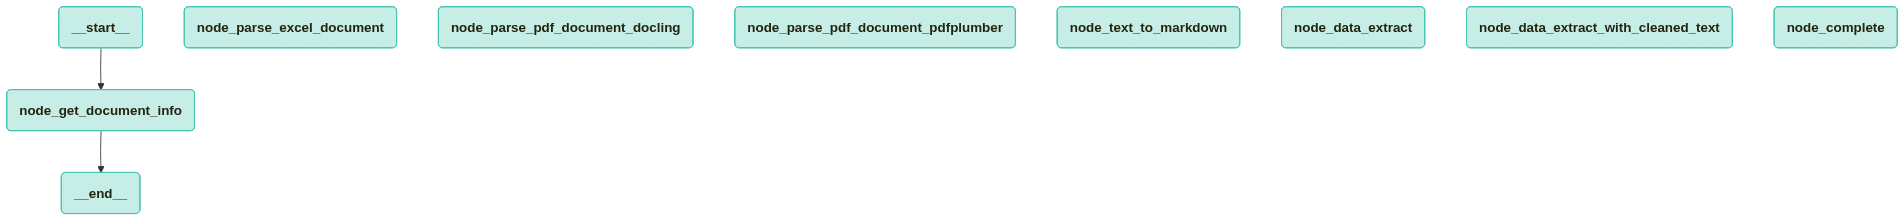

In [126]:
# 그래프 시각화
visualize_graph(graph, xray=True)

# Graph 실행

In [127]:
# graph 실행

# text 추출 태스트

# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/라이나_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(2차)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(액티브)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(퇴직)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/카디프_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/하나생명(액티브)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/iM라이프_250826.xls"
_document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/ABL_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/DB_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/KB라이프_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/KB라이프(액티브)_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_overseas_settlement/LS.pdf"

_password = None
# _password = '345678'
result = graph.invoke({"file_path": _document_file_path, "password": _password})


   file_path : /Users/bhkim/20_code_test/documents/sample_variable_annuity/ABL_250826.xlsx
   file_name : ABL_250826.xlsx
   file_ext : .xlsx
****************routing_parser****************
   .xlsx
excel_path: /Users/bhkim/20_code_test/documents/sample_variable_annuity/ABL_250826.xlsx
using pandas
****************START node_convert_text_to_markdown****************
########## text to markdown prompt ##########

  아래는 수익자가 보내온 변액일임펀드 설정/해지 지시서 파일에서 추출한 data입니다.

  아래의 추출 data를 LLM 모델이 잘 이해할 수 있도록 정리 지침에 따라 정리하세요.

  정리 지침에 따라 정리한 내용을 검수 지침에 따라 검수하세요.

  검수 오류가 발견되면 정리 내용에서 오류를 전부 수정하세요.

  검수 오류 수정이 완료되면 수정된 정리 내용을 출력 형식에 따라 출력하세요.



  ### 변액일임펀드 설정/해지 지시서 파일 내용 ###

  [=== 시트: 호스트 === 2025-08-26 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | 10 | 11 | 14 | | 17 | 18 | 21 | | 24 | 25 | 28 | | 31 | 32 | 35 | | 38 | 39 | 42 | | | | | | | | | | | | | | | 12 | 13 | 15 | | 19 | 20 | 22 | | 26 | 27 | 29 | | 33 | 34 | 36 | | 40 | 41 | 43 | | | | ※ 유동성

In [128]:
markdown_text = result["markdown_text"]
print(f"file_name : {result['file_name']}")
# print(result_markdown_text)
display(Markdown(markdown_text))


file_name : ABL_250826.xlsx


1. 메타 데이터 정리 테이블

| 항목 | 값 |
|------|----|
| 문서 제목 | 변액일임펀드 설정/해지 지시서 |
| 시트명 | 호스트 |
| 기준일자 | 2025-08-26 |
| 영업일 기준 | T일은 당일 |
| 유동성 체크 안내 | 유동성 일일체크 할것. |
| 익일 이체예상 금액 안내 | 익일 이체예상 금액은 정산손익 및 위험보험료 차감 미반영분임. |
| 투입예상금액 안내 | 익일과 익익일의 투입예상금액은 예상금액일 뿐 해당일자에 투입금액이 변동될 수 있음. |
| 총 자산총계(NAV 합계) | 56217186875 |
| 총 순유입금액(확정) | 22673164 |
| 총 순유입좌수(확정) | 7824196 |
| 총 펀드 수 | 4 |
| 펀드코드 종류 | 펀드코드_NG&S, 펀드코드_KASS |
| 수탁사 | 국민은행 (모든 펀드 공통) |
| T-1일 NAV | 2025-08-25 기준 NAV |
| T일 | 2025-08-26 기준 당일 거래일 |
| T+1일 ~ T+5일 | 영업일 기준 다음 5일 예상 거래일 |
| T+3일 ~ T+4일 펀드변경 항목 | 펀드변경에 따른 투입/인출/순투입 데이터로 구분됨 |
| NAV대비 | 순유입금액 대비 NAV 비율 (소수점 표현) |
| 합계 행 | 마지막 행은 전체 합계로, 펀드별 데이터의 합산값임 |
| 비고 | T+4일 펀드변경 순투입 항목 중 하나의 행이 펀드명과 코드가 누락된 채 데이터만 존재함 (G2003의 T+4일 펀드변경 순투입 72853939) |

2. 펀드 거래 정보 정리 테이블

| 펀드코드_NG&S | 펀드코드_KASS | 펀드명 | 수탁사 | T-1일 NAV | T일 투입금액 | T일 투입좌수 | T일 인출금액 | T일 인출좌수 | T일 순유입 확정금액 | T일 순유입 확정좌수 | T일 NAV대비 | T+1일 투입금액 | T+1일 인출금액 | T+1일 순유입예상금액 | T+1일 NAV대비 | T+2일 투입금액 | T+2일 인출금액 | T+2일 순유입예상금액 | T+2일 NAV대비 | T+3일 펀드변경 투입 | T+3일 펀드변경 인출 | T+3일 펀드변경 순투입 | T+3일 NAV대비 | T+4일 펀드변경 투입 | T+4일 펀드변경 인출 | T+4일 펀드변경 순투입 | T+4일 NAV대비 | T+5일 펀드변경 투입 | T+5일 펀드변경 인출 | T+5일 펀드변경 순투입 | T+5일 NAV대비 |
|---------------|---------------|--------|--------|------------|----------------|----------------|----------------|----------------|----------------------|----------------------|----------------|------------------|------------------|----------------------|------------------|------------------|------------------|----------------------|------------------|------------------------|------------------------|------------------------|------------------|------------------------|------------------------|------------------------|------------------|------------------------|------------------------|------------------------|------------------|
| C1005 | C1005 | 글로벌리츠(VUL) | 국민은행 | 3550698912 | 920315 | 478728 | 0 | 0 | 920315 | 478728 | 0.0002591926330023896 | 278894 | 269 | 278625 | 7.847046649276693e-05 | 411910 | 0 | 411910 | 0.00011600814662372589 | 142657 | 0 | 142657 | 4.017716047899023e-05 | 5047571 | 0 | 5047571 | 0.0014215711118003124 | 0 | 0 | 0 | 0 |
| G2003 | G2003 | 미국주식인덱스(환오픈형) | 국민은행 | 32661937215 | 13629379 | 6365275 | 0 | 0 | 13629379 | 6365275 | 0.00041728630210398864 | 78409034 | 67024047 | 11384987 | 0.00034857047593525603 | 65093322 | 15684704 | 49408618 | 0.0015127277256937804 | 23224219 | 1688 | 23222531 | 0.0007109967436143086 | 153595981 | 19040300 | 134555681 | 0.004119647898233216 | 1035650 | 0 | 72853939 | 0.0022305455589003405 |
| C100311 | C1003 | 1형 성장형(VUL) | 국민은행 | 12817066479 | 10935024 | 3237109 | 0 | 0 | 10935024 | 3237109 | 0.0008531612142229569 | 345628 | 23804519 | -23458891 | -0.0018302855055356072 | 22092 | 0 | 22092 | 1.7236393394850862e-06 | 294090 | 0 | 294090 | 2.2945188002406708e-05 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| G2005 | G2005 | 탑픽스 | 국민은행 | 7187484269 | 0 | 0 | 2811554 | 2256916 | -2811554 | -2256916 | -0.0003911735865811048 | 6383638 | 0 | 6383638 | 0.000888160274316421 | 232887 | 0 | 232887 | 3.2401740481638886e-05 | 0 | 0 | 0 | 0 | 6519389 | 160 | 6519229 | 0.0009070251503878456 | 0 | 0 | 0 | 0 |
| Total | Total | 4 | 국민은행 | 56217186875 | 25484718 | 10081112 | 2811554 | 2256916 | 22673164 | 7824196 | 0.000403313741941841 | 85417194 | 90828835 | -5411641 | -9.626310565900226e-05 | 65760211 | 15684704 | 50075507 | 0.0008907508501153545 | 23660966 | 1688 | 23659278 | 0.0004208548900286822 | 165162941 | 19040460 | 146122481 | 0.002599249253167117 | 1035650 | 0 | 72853939 | 0.0012959371154944509 | 237118789 | 0 | 0 | 0.0042179056295939925 |

In [129]:
# JSON 결과값을 테이블 형태로 시각화하는 함수
import pandas as pd
from IPython.display import HTML, display

def visualize_extraction_result(result: ExtractionResult):
    """
    ExtractionResult 객체를 테이블 형태로 시각화하는 함수
    
    Args:
        result: ExtractionResult 객체 (metadata_items, fund_rows, issues 포함)
    """
    # 메타데이터 테이블 생성
    if result.metadata_items:
        metadata_data = []
        for kv in result.metadata_items:
            metadata_data.append({
                "Key": kv.key,
                "Value": kv.value,
                # "Evidence": kv.evidence
            })
        
        df_metadata = pd.DataFrame(metadata_data)
        
        print("=" * 80)
        print("📋 메타데이터")
        print("=" * 80)
        display(df_metadata)
        print()
    
    # 펀드 행 테이블 생성
    if result.fund_rows:
        fund_rows_data = []
        for idx, fund_row in enumerate(result.fund_rows, 1):
            # 각 FundRow의 field들을 하나의 행으로 변환
            row_data = {
                "Row #": idx,
                "Row Type": fund_row.row_type,
            }
            
            # field의 각 KV를 컬럼으로 추가
            for kv in fund_row.field:
                row_data[kv.key] = kv.value
            
            # notes가 있으면 추가
            if fund_row.notes:
                row_data["Notes"] = fund_row.notes
            
            fund_rows_data.append(row_data)
        
        if fund_rows_data:
            # 모든 행에서 사용된 모든 키를 수집
            all_keys = set()
            for row in fund_rows_data:
                all_keys.update(row.keys())
            
            # 모든 행을 동일한 컬럼으로 맞춤
            for row in fund_rows_data:
                for key in all_keys:
                    if key not in row:
                        row[key] = ""
            
            df_fund_rows = pd.DataFrame(fund_rows_data)
            
            print("=" * 80)
            print("📊 펀드 행 데이터")
            print("=" * 80)
            display(df_fund_rows)
            print()
    
    # 이슈 목록 표시
    if result.issues:
        print("=" * 80)
        print("⚠️  이슈 목록")
        print("=" * 80)
        for idx, issue in enumerate(result.issues, 1):
            print(f"{idx}. {issue}")
        print()
    else:
        print("=" * 80)
        print("✅ 이슈 없음")
        print("=" * 80)
        print()


# 사용 예시
if 'result' in locals() and result.get("result"):
    visualize_extraction_result(result["result"])
else:
    print("result 변수가 없거나 result['result']가 없습니다.")

📋 메타데이터


,Key,Value
0,문서 제목,변액일임펀드 설정/해지 지시서
1,시트명,호스트
2,기준일자,2025-08-26
3,영업일 기준,T일은 당일
4,유동성 체크 안내,유동성 일일체크 할것.
5,익일 이체예상 금액 안내,익일 이체예상 금액은 정산손익 및 위험보험료 차감 미반영분임.
6,투입예상금액 안내,익일과 익익일의 투입예상금액은 예상금액일 뿐 해당일자에 투입금액이 변동될 수 있음.
7,총 자산총계(NAV 합계),56217186875
8,총 순유입금액(확정),22673164
9,총 순유입좌수(확정),7824196



📊 펀드 행 데이터


,Row #,Row Type,펀드코드_NG&S,펀드코드_KASS,펀드명,수탁사,T-1일 NAV,T일 투입금액,T일 투입좌수,T일 인출금액,...,T+3일 NAV대비,T+4일 펀드변경 투입,T+4일 펀드변경 인출,T+4일 펀드변경 순투입,T+4일 NAV대비,T+5일 펀드변경 투입,T+5일 펀드변경 인출,T+5일 펀드변경 순투입,T+5일 NAV대비,Notes
0,1,fund,C1005,C1005,글로벌리츠(VUL),국민은행,3550698912,920315,478728,0,...,4.017716047899023e-05,5047571,0,5047571,0.0014215711118003124,0,0,0,0,
1,2,fund,G2003,G2003,미국주식인덱스(환오픈형),국민은행,32661937215,13629379,6365275,0,...,0.0007109967436143086,153595981,19040300,134555681,0.004119647898233216,1035650,0,72853939,0.0022305455589003405,T+5일 펀드변경 순투입 값은 비고에 명시된 72853939와 일치
2,3,fund,C100311,C1003,1형 성장형(VUL),국민은행,12817066479,10935024,3237109,0,...,2.2945188002406708e-05,0,0,0,0,0,0,0,0,
3,4,fund,G2005,G2005,탑픽스,국민은행,7187484269,0,0,2811554,...,0,6519389,160,6519229,0.0009070251503878456,0,0,0,0,
4,5,summary,Total,Total,4,국민은행,56217186875,25484718,10081112,2811554,...,0.0004208548900286822,165162941,19040460,146122481,0.002599249253167117,1035650,0,72853939,0.0012959371154944509,T+5일 펀드변경 순투입 값은 비고에 명시된 72853939와 일치



⚠️  이슈 목록
1. T+5일 펀드변경 순투입 항목에서 G2003 펀드의 값(72853939)이 비고에 명시된 값과 일치하며, 합계 행의 T+5일 펀드변경 순투입 값도 동일하여 데이터 일관성 확인



In [130]:
print(result["result"])

metadata_items=[KV(key='문서 제목', value='변액일임펀드 설정/해지 지시서'), KV(key='시트명', value='호스트'), KV(key='기준일자', value='2025-08-26'), KV(key='영업일 기준', value='T일은 당일'), KV(key='유동성 체크 안내', value='유동성 일일체크 할것.'), KV(key='익일 이체예상 금액 안내', value='익일 이체예상 금액은 정산손익 및 위험보험료 차감 미반영분임.'), KV(key='투입예상금액 안내', value='익일과 익익일의 투입예상금액은 예상금액일 뿐 해당일자에 투입금액이 변동될 수 있음.'), KV(key='총 자산총계(NAV 합계)', value='56217186875'), KV(key='총 순유입금액(확정)', value='22673164'), KV(key='총 순유입좌수(확정)', value='7824196'), KV(key='총 펀드 수', value='4'), KV(key='펀드코드 종류', value='펀드코드_NG&S, 펀드코드_KASS'), KV(key='수탁사', value='국민은행 (모든 펀드 공통)'), KV(key='T-1일 NAV', value='2025-08-25 기준 NAV'), KV(key='T일', value='2025-08-26 기준 당일 거래일'), KV(key='T+1일 ~ T+5일', value='영업일 기준 다음 5일 예상 거래일'), KV(key='T+3일 ~ T+4일 펀드변경 항목', value='펀드변경에 따른 투입/인출/순투입 데이터로 구분됨'), KV(key='NAV대비', value='순유입금액 대비 NAV 비율 (소수점 표현)'), KV(key='합계 행', value='마지막 행은 전체 합계로, 펀드별 데이터의 합산값임'), KV(key='비고', value='T+4일 펀드변경 순투입 항목 중 하나의 행이 펀드명과 코드가 누락된 채 데이터만 존재함 (G2003의 T+4일 펀드변경 순투입 